In [1]:
import numpy as np

In [6]:

class LinearRegression:
    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # init parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # gradient descent
        for _ in range(self.n_iters):
            y_predicted = np.dot(X, self.weights) + self.bias
            
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    
    def predict(self, X):
        y_predicted = np.dot(X, self.weights) + self.bias
        return y_predicted
        

## Test implementation

In [3]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

In [4]:
X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

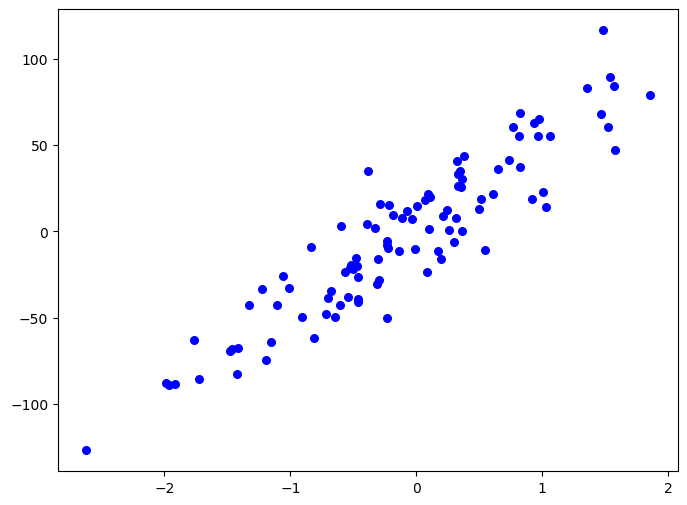

In [5]:
fig = plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], y, color='b', marker='o', s=30)
plt.show()

In [7]:
lr = LinearRegression(lr=0.01, n_iters=1000)
lr.fit(X_train, y_train)
predictions = lr.predict(X_test)
print(predictions)

[-61.87673067  69.25196796  38.15917438 -18.1336185  -10.75235929
 -13.44123283 -21.573971   -82.1975523   38.59734866  43.70858704
  48.36849522  16.87761971 -56.86059834 -24.56612708 -53.59649012
 -22.20223451  45.77709995  11.49662257  34.69837079  17.74612146]


In [8]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [9]:
print("MSE:", mse(y_test, predictions))

MSE: 417.00933221477027
